# Fermi GBM Localization of GRB 190114C using the DoL 

The `dol` provides modules capable of creating the same legacy ground localizations that are produced by the GBM Science Team. These python modules exactly replicate the operations of the original Fortran code. You can find documention on DoL localizations with the GDT here: https://astro-gdt.readthedocs.io/projects/astro-gdt-fermi/en/latest/missions/fermi/gbm/localization/dol/dol.html

The remainder of this page will focus on creating an example ground localization for GRB 190114C / GRB 190114.873

We will download GBM data using the GDT but you can manually download GBM GRB data from the catalog on HEASARC: https://heasarc.gsfc.nasa.gov/W3Browse/fermi/fermigbrst.html or https://heasarc.gsfc.nasa.gov/FTP/fermi/data/gbm/bursts/

First, create the directory `/shared/fermi-data/` in the FermiBottle. Then input the GRB and the path below:

In [1]:
grb = '190114873'
data_path = '/shared/fermi-data/{}/'.format(grb)

### Preparing Data for Localization

The first step to creating a ground localization is obtaining data near the time of a burst. For simplicity, we will work with a TRIGDAT file because it conventiently contains binned data for all detectors as well as position history information about the spacecraft. However, any `GbmPhaii` formatted data (e.g., TTE, CSPEC, CTIME) and `GbmPosHist` (i.e., POSTHIST) combination will work as long as the data are binned into the same energy bins as the TRIGDAT files.

We begin data preparation by downloading the TRIGDAT file `glg_trigdat_all_bn191014873_v02.fit` to our local directory using the `TriggerFinder` class initialized with GBM burst number.

In [2]:
import glob
import matplotlib.pyplot as plt 
import numpy as np
from gdt.missions.fermi.gbm.finders import TriggerFinder

# initialize TriggerFinder to pull data for GRB
data_finder = TriggerFinder(grb)
data_finder.get_trigdat(data_path, verbose=True)

Output()

[PosixPath('/shared/fermi-data/190114873/glg_trigdat_all_bn190114873_v02.fit')]

### Open the TRIGDAT file

In [3]:
from gdt.missions.fermi.gbm.trigdat import Trigdat
trigdat_path = data_path + 'glg_trigdat_all_bn190114873_v02.fit'
trigdat = Trigdat.open(trigdat_path)

We then plot a summed lightcurve for all triggered detectors. You can select the binning timescale and energy range that you would like to use. For this lightcurve, we specify a minimum binning timescale of 1.024 s. Shorter binnings (e.g., 256 and 64 milliseconds) are more appropriate for short GRBs. Generally, we remove the first and last energy bins to provide a clean background fit and good signal selection. However localization is done in the 50-300 keV range regardless of your energy selection.

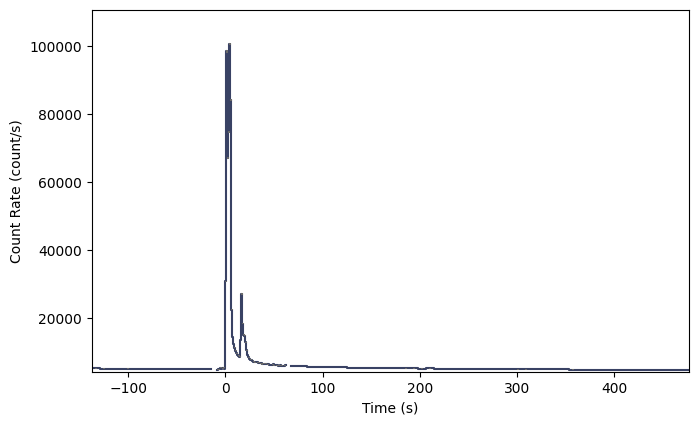

In [4]:
# Define time binning and energy range for our analysis
timescale = 1024  # time resolution in milliseconds
emin = 10.0       # minimum energy in keV
emax = 800.0      # maximum energy in keV

# Plot the lightcurve
from gdt.core.plot.lightcurve import Lightcurve
trigdet = trigdat.triggered_detectors
summed_phaii = trigdat.sum_detectors(trigdet, timescale=timescale)
summed_phaii = summed_phaii.slice_energy((emin, emax))
lcplot = Lightcurve(summed_phaii.to_lightcurve())

### Adjusting the lightcurve view

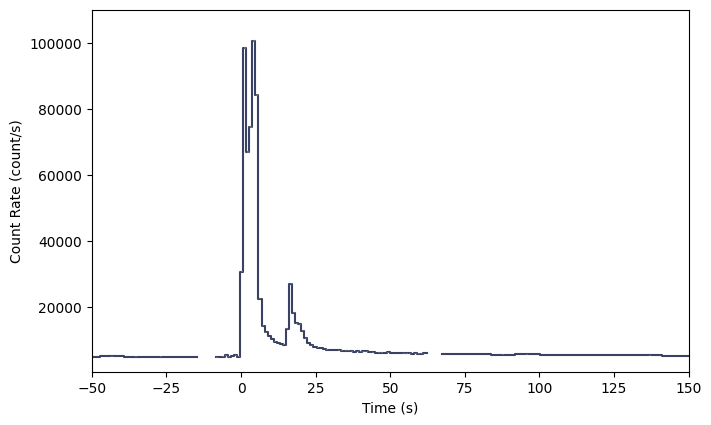

In [5]:
# Adjust the x-axis and y-axis limits
xmin = -50
xmax = 150
ymin = 500
ymax = 110000

lcplot = Lightcurve(summed_phaii.to_lightcurve())
lcplot.xlim = (xmin, xmax)
lcplot.ylim = (ymin, ymax)

**Multiple Timescales**

The lightcurve data has multiple resolutions. There are “background” time bins of duration 8.124 s from the start of the trigger data to just before trigger time, and then about 50 s after the trigger time through the rest of the data. In between the two segments of “background” bins, there are 1.024 s duration bins, and in a very short window around the trigger time, there are overlapping bins of width 256 and 64 ms. This design enables a preliminary rapid analysis for long duration triggers that can last from several tens of seconds down sub-second duration triggers. The fact that the different bin timescales are overlapping creates difficulty if you want to make lightcurve plots, but the `Trigdat` class solves this problem for you.

### Selecting the source interval (and multiple pulses)

The GRB appears in the lightcurve as two pulses from the trigger time until about 25 s afterwards. Localization is performed by taking the detector response at the central time of the source window. It does not account for spacecraft motion so you should limit the source window length to no more than 20 s, even for long GRBs. It is recommended to fit the brightest peak when using the DoL algorithm to localize GRBs with durations longer than 1 minute. 

If there are multiple and well-separated pulses, it is also good to localize each pulse individually to make sure they localize to the same sky position. GBM has a large FOV and can have emission from different sources within "short" time intervals.

We will select the first pulse to localize. We will now retrieve the observed counts in this window while also creating a new lightcurve with the source period highlighted.

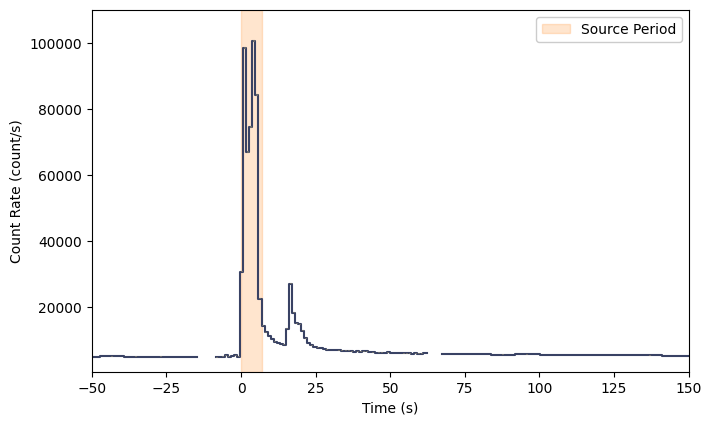

In [6]:
# Define source (signal) interval
src_interval = (0., 7.)

# Plot the lightcurve with source selection
lcplot = Lightcurve(summed_phaii.to_lightcurve())
ax = plt.gca()
src_span = ax.axvspan(*src_interval, color='C1', alpha=0.2)
l2 = plt.legend([src_span], ["Source Period"], framealpha=1.0)
lcplot.xlim = (xmin, xmax)
lcplot.ylim = (ymin, ymax)

In [7]:
# Print observed source counts in each detector
src_counts = []
src_exposure = []

for det in trigdat._detectors:
    
    # convert the trigdat file to binned data
    phaii = trigdat.to_phaii(det, timescale=timescale)
    
    # bin the detector counts over the source interval
    bin = phaii.data.integrate_time(*src_interval)
    src_counts.append(bin.counts.astype(np.int32))
    src_exposure.append(bin.exposure)
    print(f" - {det} {src_counts[-1]}")
    
avg_src_exposure = np.sum(src_exposure) / np.array(src_exposure).size

 - n0 [  899  3366  3758  7415 14409  3429  1438  1045]
 - n1 [  727  2870  2928  6231 13422  3148  1365   880]
 - n2 [  797  2816  3222  9457 22235  4732  2162   754]
 - n3 [ 3266 16300 16134 23886 37094  6550  2247  1032]
 - n4 [ 2973 16089 16777 24116 38089  6598  2567   812]
 - n5 [  524  1769  2579  5947 12552  2548  1569   468]
 - n6 [ 2289 10357 11009 18757 30483  5702  2197   532]
 - n7 [ 3493 16386 15616 22346 35596  6506  2205   855]
 - n8 [ 3044 16654 15547 22851 35758  6345  2415   860]
 - n9 [ 612 3147 2451 3042 5873 1474 1178  271]
 - na [ 882 3034 2460 2300 4621 1247 1060  429]
 - nb [ 585 3109 2234 2384 4519 1037  594  739]
 - b0 [54073 24228 11827  4794   641   342   185   808]
 - b1 [45333 26710 10333  3619   542   292   170   607]


### Fitting the Background

Next, we will need an estimate for the background counts within the source window. We perform the fit on two background periods, one just before and one just after the source window. Try to select smooth regions near to but excluding the burst. Too long an interval results in the fitter wasting its degrees of freedom accommodating irrelevant wiggles. Too short an interval results in significant statistical errors in the background estimation. Select the lowest order polynomial that gives a good fit to the background.

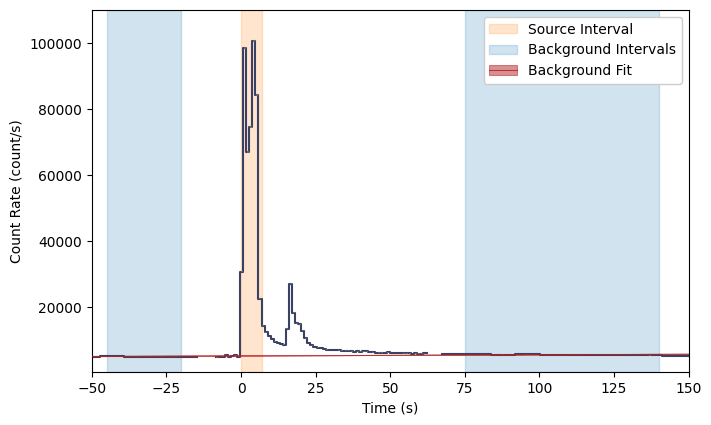

In [8]:
from gdt.core.background.fitter import BackgroundFitter
from gdt.core.background.binned import Polynomial

# Define the background interval
bg_times = [(-45., -20.), (75, 140)]
poly_order = 1

bg_counts = []
bg_exposure = []
bg_trigdet = []
model_bg_counts = []

# Fit each detector individually
for det in trigdat._detectors:
    
    # convert the trigdat file to binned data
    phaii = trigdat.to_phaii(det, timescale=timescale)
    
    # fit the background
    fitter = BackgroundFitter.from_phaii(phaii, Polynomial, time_ranges=bg_times)
    fitter.fit(order=1)

    # interpolate the background fit over the file
    bg_rates = fitter.interpolate_bins(phaii.data.tstart, phaii.data.tstop)
    # integrate background rates through the source
    bin = bg_rates.integrate_time(*src_interval)
    
    bg_counts.append(bin.counts.astype(np.int32))
    bg_exposure.append(bin.exposure)
    model_bg_counts = bg_rates.rates * bin.exposure

    # Save the background rates in selected energy range
    if det in trigdet:
        bg_trigdet.append(bg_rates.slice_energy(emin, emax))

avg_bg_exposure = np.sum(bg_exposure) / np.array(bg_exposure).size
bg_trigdet_sum = bg_trigdet[0].sum_time(bg_trigdet)


# Plot the lightcurve with the background fit
lcplot = Lightcurve(summed_phaii.to_lightcurve())
ax = plt.gca()

# plot the source and background selections
src_span = ax.axvspan(*src_interval, color='C1', alpha=0.2)
bg_span = ax.axvspan(*bg_times[0], color='C0', alpha=0.2)
ax.axvspan(*bg_times[1], color='C0', alpha=0.2)

# plot the background fit
lcplot.set_background(bg_trigdet_sum)

# make it pretty
l3 = plt.legend([src_span, bg_span, tuple(lcplot._bkgd._artists)],
                ["Source Interval", "Background Intervals", "Background Fit"], framealpha=1.0,)
lcplot.xlim = (xmin, xmax)
lcplot.ylim = (ymin, ymax)

### Getting the spacecraft information

We also need the position and rotation of the spacecraft to determine the conversion between the spacecraft coordinates, where the localization calculation is performed, and sky (i.e., Equatorial) coordinates.

In [9]:
from gdt.missions.fermi.time import Time

tcenter = trigdat.trigtime + 0.5 * sum(src_interval)
frame = trigdat.poshist.at(Time(tcenter, format='fermi'))
scpos = frame.obsgeoloc.xyz.to_value('km') # spacecraft position in km to Earth center
quaternion = frame.quaternion.scalar_last # spacecraft rotation

# Set the initial localization guess from the FSW location
ra = trigdat.headers['PRIMARY']['RA_OBJ']
dec = trigdat.headers['PRIMARY']['DEC_OBJ']
energies = np.concatenate([phaii.data.emin, [phaii.data.emax[-1]]])

**Non-GRB Transients**

Transients with softer spectra than GRBs, such as Soft Gamma-ray Repeaters (SGRs) and Solar Flares, typically benefit from localizations performed over a 5-50 keV energy range instead of the default 50-300 keV range. This can be done by using the 5-50 keV response file prepared only for the default soft spectrum.

In [22]:
from gdt.missions.fermi.gbm.localization.dol import legacy_spectral_models

# User selection
channels_selection = 'low'

if channels_selection == 'standard':
    crange = np.array([3, 4], dtype=np.int32)
elif channels_selection == 'low':
    crange = np.array([1, 2], dtype=np.int32)

if np.array_equal(crange, [1, 2]):
    spec = [("Soft: ", legacy_spectral_models.band_soft)]
    locrates = [legacy_spectral_models.band_soft_5_50]
else:
    spec = None
    locrates = None

### Performing the Localization

In [19]:
from gdt.missions.fermi.gbm.localization.dol.legacy_dol import legacy_DoL, legacy_dtorad

# Run the DoL
dol = legacy_DoL(spec=spec, locrates=locrates, verbose=False)
loc = dol.eval(crange, np.array(src_counts), np.array(bg_counts),
               avg_src_exposure, avg_bg_exposure, scpos, quaternion, 
               energies, ra, dec, int(tcenter), 1, grb, data_path)

# Extract best localization parameters
grb_ra = loc['best']['ra'] * legacy_dtorad
grb_dec = loc['best']['dec'] * legacy_dtorad
grb_err = loc['best']['err']
nchi2 = loc['best']['nchi2']
print ('\nBest Location: RA = {:.3f}, Dec = {:.3f}, Stat. Error = {:.3f}, Norm Chi^2 = {:.3f}\n'.format(grb_ra, grb_dec, grb_err, nchi2))


Best Location: RA = 52.667, Dec = -28.045, Stat. Error = 1.000, Norm Chi^2 = 0.227



### Plot skymap

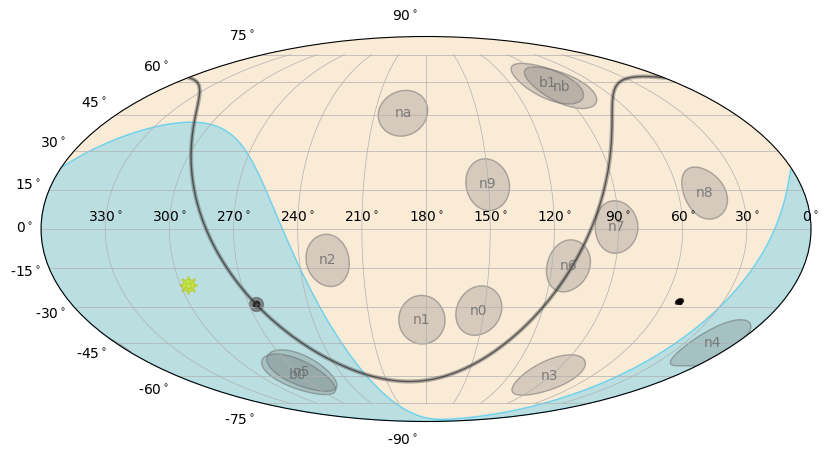

In [23]:
from gdt.core.plot.sky import EquatorialPlot
from gdt.missions.fermi.gbm.localization import Chi2Grid, GbmHealPix, hitl_model

# To create healpix map, load Chi2Grid and assign metadata
chi2grid_file = '{}/chi2grid_bn{}_*.dat'.format(data_path, grb)
chi2grid_file = glob.glob(chi2grid_file)[-1]
chi2grid = Chi2Grid.open(chi2grid_file)
chi2grid.quaternion = quaternion
chi2grid.scpos = scpos * 1e3 
chi2grid.trigtime = trigdat.trigtime

# Create initial from_chi2grid map just to get the raw prob array
grb_loc = GbmHealPix.from_chi2grid(chi2grid, nside=512)

# Apply convolution with systematic uncertainty
grb_loc = grb_loc.convolve(hitl_model, np.degrees(loc["best"]["az"]))

# Plot localization
skyplot = EquatorialPlot()
skyplot.add_localization(grb_loc, gradient=True)
plt.savefig(f"{data_path}/final_localization_bn{grb}.png")

The contours mark the 90% and 50% containment areas defined by the statistical+systematic uncertainty of the observed counts. We can apply the systematic uncertainty defined for human-in-the-loop (HITL) ground localizations by convolving the statistical map with hitl_model(). This method applies a core + tail model with two Gaussian smoothings whose widths are determined by the best-fit azimuth value in degrees. See [1] for more details on the derivation of this systematic